# Geographic hold-out audit of a COI reference library

Pick a genus, run everything. The notebook downloads public COI records from BOLD and GenBank, cleans and aligns them, and then identifies the same queries twice: with the query's region missing from the library and with its whole continent missing. It reports how many identifications change, why, which reference records cause the most failures, and what the 1% rule costs.

Needs MAFFT on the PATH. The first run for *Bombus* takes a few minutes if the downloads are already in `work/`, otherwise up to an hour.

In [1]:
GENUS = "Bombus"
WORKDIR = "work/bombus"

In [2]:
import holdout as hd
from holdout import plots

hd.use(GENUS, WORKDIR)
hd.prepare(GENUS, WORKDIR);

download_bold      already done
download_genbank   already done
build_dataset      already done
cap_species        already done
align              already done
encode_alignment   already done
flag_outliers      already done
specimen_keys      already done
eligibility        already done


## How much changes

In [3]:
res = hd.run()
s = res.summary
print(f"{s['queries']:,} queries of {s['species']} species")
print(f"net change in expected recall: {s['net_change_pp']:+.2f} pp "
      f"(95% CI {s['net_change_ci_pp'][0]:+.1f} to {s['net_change_ci_pp'][1]:+.1f})")
print(f"queries that changed outcome: {100*s['changed_outcome_species_weighted']:.1f}% species-weighted, "
      f"{100*s['changed_outcome_pooled']:.1f}% pooled")
print(f"unique correct -> wrong: {100*s['U_to_W']:.1f}%   ambiguous -> unique correct: {100*s['A_to_U']:.1f}%")

3,388 queries of 28 species
net change in expected recall: +0.04 pp (95% CI -11.1 to +8.7)
queries that changed outcome: 19.7% species-weighted, 31.7% pooled
unique correct -> wrong: 6.6%   ambiguous -> unique correct: 23.1%


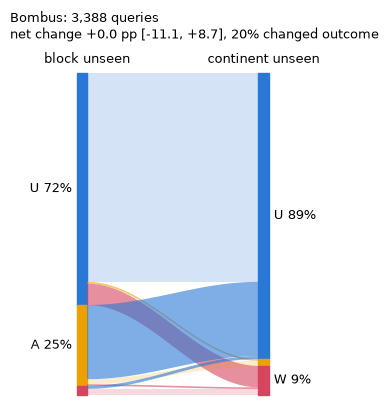

In [4]:
plots.turnover(res);

In [5]:
res.transitions

,block_unseen,continent_unseen,queries,share
0,A,A,53,0.015643
1,A,U,781,0.230519
2,A,W,17,0.005018
3,U,A,19,0.005608
4,U,U,2202,0.649941
5,U,W,225,0.066411
6,W,A,1,0.000295
7,W,U,31,0.009150
8,W,W,59,0.017414


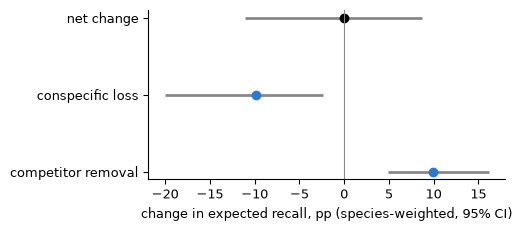

In [6]:
plots.components(res);

## Species that change most

In [7]:
res.species.head(10)

,species,queries,recall_block,recall_continent,changed,U_to_W,A_to_U
0,Bombus humilis,89,0.893258,0.000000,0.955056,74,0
1,Bombus monticola,151,0.933775,0.000000,0.933775,141,0
2,Bombus lapidarius,249,0.594378,1.000000,0.811245,0,202
3,Bombus lucorum,518,0.749035,0.976834,0.455598,0,236
4,Bombus terrestris,524,0.742366,0.953244,0.421756,5,201
5,Bombus ruderatus,23,0.782609,1.000000,0.391304,0,8
6,Bombus lapponicus,173,0.737958,0.895954,0.346821,4,51
7,Bombus cryptarum,240,0.852083,0.952083,0.333333,1,50
8,Bombus muscorum,25,0.880000,1.000000,0.240000,0,6
9,Bombus bohemicus,79,0.778481,0.867089,0.164557,0,12


## Records worth checking

Reference records whose removal would resolve the most ambiguous or wrong identifications. These are candidates, not proven errors.

In [8]:
res.influential.head(10)

,record_id,label,source,country,bin,resolved,worsened,net,affects
0,GBAAM604-25,Bombus terrestris,both,Slovenia,BOLD:AAB1060,462.0,0.0,462.0,lucorum 462
1,GBAAM531-25,Bombus lucorum,both,Slovenia,BOLD:AAB1062,433.0,0.0,433.0,terrestris 433
2,MN652870.1,Bombus terrestris,GenBank,Spain,NaN,372.0,0.0,372.0,lapidarius 372
3,WASPS2453-22,Bombus vandykei,BOLD,Canada,BOLD:ACE3465,111.0,0.0,111.0,flavifrons 111
4,GMGRB1354-13,Bombus ashtoni,BOLD,Germany,BOLD:AAD2530,102.0,0.0,102.0,bohemicus 102
5,LPRCW595-21,Bombus renardi,BOLD,France,BOLD:AAB1060,99.0,0.0,99.0,lucorum 99
6,ABG661-22,Bombus fervidus,BOLD,Canada,BOLD:AAB0152,34.0,0.0,34.0,rufocinctus 34
7,UAMIC4628-23,Bombus bohemicus,BOLD,United States,BOLD:AAB6714,32.0,0.0,32.0,flavidus 32
8,MDHQD2661-25,Bombus ternarius,BOLD,Canada,BOLD:AAA8078,29.0,0.0,29.0,sylvicola 29
9,MN652873.1,Bombus terrestris,GenBank,Spain,NaN,25.0,0.0,25.0,pascuorum 25


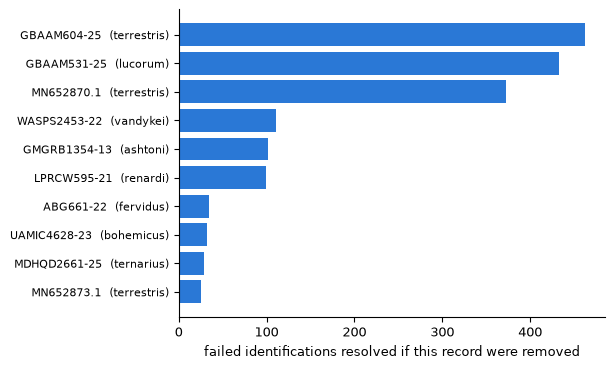

In [9]:
plots.influential(res);

In [10]:
res.removal_curve

,removed,resolved,worsened,share_of_failures
0,1,462,0,0.128548
1,5,1480,0,0.411797
2,10,1699,0,0.472732
3,20,1838,0,0.511408
4,50,1941,1,0.540067


## The 1% rule

Give a single species only if no other species lies within 1%. The rule can only withhold answers, so the question is how many correct ones it gives up per error it removes.

In [11]:
res.rule

,scenario,queries,single_P0,single_P1,wrong_among_single_P0,wrong_among_single_P1,wrong_withheld,correct_withheld,correct_per_wrong
0,block unseen,6683,0.821787,0.442466,0.030408,0.021305,104,2431,23.375000
1,continent unseen,3388,0.970189,0.682704,0.085488,0.007350,264,710,2.689394


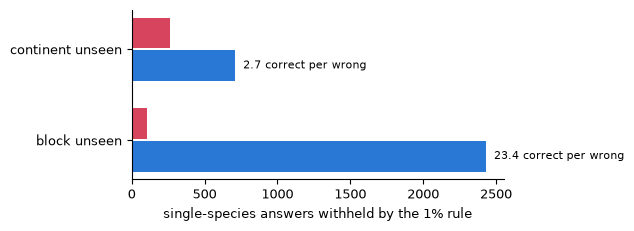

In [12]:
plots.rule_cost(res);

In [13]:
print("saved to", res.save())

saved to work/bombus/results/audit
